In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("Train.csv")

print(data.shape)
data.head()

(10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [3]:
for col in data.select_dtypes(include=np.number):
    data[col].fillna(data[col].median(), inplace=True)

for col in data.select_dtypes(include='object'):
    data[col].fillna(data[col].mode()[0], inplace=True)

/tmp/ipykernel_3020/1885363860.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)
/tmp/ipykernel_3020/1885363860.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [4]:
encoder = LabelEncoder()

for col in data.select_dtypes(include='object'):
    data[col] = encoder.fit_transform(data[col])

In [6]:
target = data.columns[-1]

X = data.drop(columns=[target])
y = data[target]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
log_model = LogisticRegression(max_iter=200)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("\nLogistic Regression Model Trained!")


Logistic Regression Model Trained!


In [13]:
rf_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=6,
    random_state=0
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\nRandom Forest Model Trained!")


Random Forest Model Trained!


In [15]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, log_pred))

print("\nRandom Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.6476363636363637

Random Forest Accuracy: 0.6847272727272727


In [16]:
print("\n--- Logistic Regression Report ---")
print(classification_report(y_test, log_pred))

print("\n--- Random Forest Report ---")
print(classification_report(y_test, rf_pred))


--- Logistic Regression Report ---
              precision    recall  f1-score   support

           0       0.57      0.62      0.59      1135
           1       0.72      0.67      0.69      1615

    accuracy                           0.65      2750
   macro avg       0.64      0.64      0.64      2750
weighted avg       0.65      0.65      0.65      2750


--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.57      0.98      0.72      1135
           1       0.97      0.48      0.64      1615

    accuracy                           0.68      2750
   macro avg       0.77      0.73      0.68      2750
weighted avg       0.81      0.68      0.67      2750



In [17]:
if accuracy_score(y_test, rf_pred) > accuracy_score(y_test, log_pred):
    print("Random Forest performs better")
else:
    print("Logistic Regression performs better")

Random Forest performs better


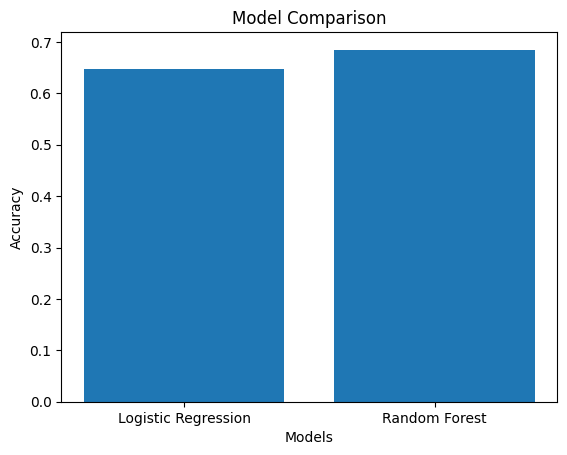

In [19]:
models = ['Logistic Regression', 'Random Forest']

log_acc = accuracy_score(y_test, log_pred)
rf_acc = accuracy_score(y_test, rf_pred)

scores = [log_acc, rf_acc]

plt.figure()
plt.bar(models, scores)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()